<div style="font-size:12px; text-align: justify;">

<b>Turning Logistics into Loyalty: An Analysis of Delivery Delays and Customer Repeat Purchase in Olist 2018</b>

<p>
<b>A. Olist Dataset</b><br><br>
Olist is a Software as a Service (SaaS) e-commerce company from Brazil. Olist helps small and medium businesses sell their products on many marketplaces using one system. By using technology, Olist acts as an aggregator that connects small sellers with national and global online sales channels, such as Mercado Livre and Amazon. In the Olist system, one order can include multiple items and can be delivered by different sellers or logistics partners. This causes differences in delivery time between orders. After receiving the order, or when the delivery estimate is passed, customers can give reviews with scores and comments. This dataset allows analysis of the relationship between delivery time, customer satisfaction, and repeat purchase behavior. Logistics is an important part of e-commerce, especially in a large country like Brazil. Late delivery can affect customer experience and increase the risk of customers not buying again. The main hypothesis of this study is that late delivery is associated with lower review scores and lower repeat purchase rates, especially for customers’ first purchase experience.
</p>

<p>
<b>B. Tujuan Study Case</b><br><br>
The goal of this case study is to analyze the relationship between delivery delay and customer experience, with a focus on:
</p>

<p>
1. Identifying which logistics process has the most delays.<br>
2. Understanding whether late delivery affects customer review scores.<br>
3. Analyzing whether the first delivery experience affects customer repeat purchases.<br>
4. Understanding the main reasons for customer complaints from negative review comments.
</p>

<p>
The results of this analysis are expected to help Olist improve logistics performance and increase customer satisfaction.
</p>

<p>
<b>Proses Analisis:</b><br><br>
<b>1. Ask</b><br>
a) <b>Business Task</b><br>
• What is the difference in review scores between on-time delivery and late delivery?<br>
• Which logistics stage takes the longest time on average?<br>
• Does late delivery in the first order relate to a lower repeat purchase rate?<br>
• Is late delivery related to an increase in negative reviews?
</p>

<p>
b) <b>Stakeholders</b><br>
• Olist Operations & Logistics Team<br>
• Customer Experience Team<br>
• Olist Management & Executives<br>
• Data Analyst / Business Intelligence Team
</p>

<p>
<b>2. Prepare</b><br>
a) <b>Data Used</b><br>
This study uses the Brazilian E-Commerce Public Dataset by Olist. The dataset includes 9 main tables from 2016 to 2018. To keep the analysis focused, this case study:
</p>

<p>
• Uses data from 2018 only<br>
• Uses 6 core datasets, as listed below:<br>
• olist_orders_dataset.csv – Order data (time and status)<br>
• olist_customers_dataset.csv – Unique customer data and location<br>
• olist_order_items_dataset.csv – Product details, price, and shipping cost<br>
• olist_products_dataset.csv – Product category information<br>
• olist_order_reviews_dataset.csv – Review scores and customer comments<br>
• olist_order_payments_dataset.csv – Payment methods and installments
</p>

b) <b>Data Structure</b><br>
| Column Name                     | Description                         | Use in Analysis                                                                 |
| ------------------------------- | ----------------------------------- | ------------------------------------------------------------------------------- |
| order_id                        | Unique transaction ID               | Primary key to join order, item, review, and payment data                        |
| customer_id                     | Customer ID per order               | Identifies the customer at the single order level                                |
| customer_unique_id              | Unique customer ID                  | Used to analyze repeat purchases and customer cohorts                            |
| order_status                    | Order status                        | Filters valid orders (delivered) for logistics analysis                          |
| order_purchase_timestamp        | Order creation time                 | Start point of the logistics process                                             |
| order_approved_at               | Payment approval time               | Measures payment approval time (purchase → approved)                             |
| order_delivered_carrier_date    | Order sent to carrier               | Start of physical delivery (handling stage)                                      |
| order_delivered_customer_date   | Order received by customer          | End of logistics process and base for delay calculation                          |
| order_estimated_delivery_date   | Estimated delivery date             | SLA reference to define on-time or late delivery                                  |
| customer_city                   | Customer city                       | Analyzes delivery delays by city                                                 |
| customer_state                  | Customer state                      | Identifies regions with higher delay risk                                        |
| product_id                      | Product ID                          | Product context within an order (analysis control)                                |
| product_category_name           | Product category                    | Analyzes product categories with higher delay risk                               |
| price                           | Product price                       | Control variable related to customer expectations                                 |
| freight_value                   | Shipping cost                       | Context of shipping cost versus delivery speed expectation                        |
| payment_value                   | Total payment value                 | Validates transaction value for repeat purchase analysis                          |
| payment_type                    | Payment method                      | Supporting variable for payment behavior                                         |
| payment_installments            | Number of installments              | Indicates customer price sensitivity                                             |
| review_score                    | Satisfaction score (1–5)            | Main indicator of customer satisfaction                                          |
| review_comment_message          | Customer comment                    | Used to analyze complaint themes from negative reviews (score ≤ 3)               |

<b>c) Data Accessibility and Privacy</b>

<p>
This dataset is public and available on Kaggle. All data is fully anonymized, and there is no personal customer information contained in the dataset. 
Because of this, the data is safe to use for non-commercial analysis, academic purposes, and case studies without violating privacy or data protection regulations.
</p>

<b>d) ROCCC Data Assessment</b>

<p>
The dataset quality is evaluated using the ROCCC framework:
</p>

<p>
• <b>Reliable:</b> The data comes from a real e-commerce system used by Olist.<br>
• <b>Original:</b> The data includes raw transaction and logistics records.<br>
• <b>Comprehensive:</b> The data covers orders, logistics, payments, products, and reviews.<br>
• <b>Current:</b> The data is suitable for historical analysis (up to 2018).<br>
• <b>Cited:</b> The dataset is officially published by Olist.
</p>
</div>

In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from scipy.stats import mannwhitneyu
from IPython.display import display

Load Dataset

In [2]:
# Dataset Description
# =====================================================
# olist_orders_dataset        : Main order data (timestamps & status)
# olist_customers_dataset     : Unique customer & location data
# olist_order_items_dataset   : Product details, price, & freight cost
# olist_products_dataset      : Product category information
# olist_order_reviews_dataset : Review scores & text feedback
# olist_order_payments_dataset: Payment method & installment details

# Making function to load CSV files
def load_csv(
    path,
    usecols,
    dtypes=None,
    datetime_cols=None,
    filter_year=None,
    filter_col=None
):

# Load CSV with selected columns, optimized dtypes, optional datetime parsing, and optional year filtering.
# Read CSV with selected columns and data types
    df = pd.read_csv(path, usecols=usecols, dtype=dtypes)

# Convert specified columns to datetime
    if datetime_cols:
        for col in datetime_cols:
            df[col] = pd.to_datetime(
                df[col],
                errors='coerce',
                format='%Y-%m-%d %H:%M:%S' 
            )

# Filter data by year (only 2018 order)
    if filter_year and filter_col:
        df = df[df[filter_col].dt.year == filter_year]

    return df

# Load data one by one
# --- Orders ---
orders = load_csv(
    path=r'C:\Python\Project\Olist\olist_orders_dataset.csv',
    usecols=[
        'order_id',
        'customer_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ],
    dtypes={
        'order_id': 'str',
        'customer_id': 'str',
        'order_status': 'category'
    },
    datetime_cols=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ],
    filter_year=2018,
    filter_col='order_purchase_timestamp'
)

# --- Customers ---
customers = load_csv(
    path=r'C:\Python\Project\Olist\olist_customers_dataset.csv',
    usecols=[
        'customer_id',
        'customer_unique_id',
        'customer_city',
        'customer_state'
    ],
    dtypes={
        'customer_id': 'str',
        'customer_unique_id': 'str',
        'customer_city': 'category',
        'customer_state': 'category'
    }
)

# --- Order Items ---
order_items = load_csv(
    path=r'C:\Python\Project\Olist\olist_order_items_dataset.csv',
    usecols=[
        'order_id',
        'product_id',
        'price',
        'freight_value'
    ],
    dtypes={
        'order_id': 'str',
        'product_id': 'str',
        'price': 'float32',
        'freight_value': 'float32'
    }
)

# --- Product ---
products = load_csv(
    path=r'C:\Python\Project\Olist\olist_products_dataset.csv',
    usecols=[
        'product_id',
        'product_category_name'
    ],
    dtypes={
        'product_id': 'str',
        'product_category_name': 'category'
    }
)

# --- review ---
reviews = load_csv(
    path=r'C:\Python\Project\Olist\olist_order_reviews_dataset.csv',
    usecols=[
        'order_id',
        'review_score',
        'review_comment_message'
    ],
    dtypes={
        'order_id': 'str',
        'review_score': 'int8',
        'review_comment_message': 'str'
    }
)

# --- payment ---
payments = load_csv(
    path=r'C:\Python\Project\Olist\olist_order_payments_dataset.csv',
    usecols=[
        'order_id',
        'payment_type',
        'payment_installments',
        'payment_value'
    ],
    dtypes={
        'order_id': 'str',
        'payment_type': 'category',
        'payment_installments': 'int8',
        'payment_value': 'float32'
    }
)

# Aggregate payments (1 order = 1 payment)
payments_agg = (
    payments
    .groupby('order_id', as_index=False)
    .agg(
        payment_type=('payment_type', 'first'),
        payment_installments=('payment_installments', 'max'),
        payment_value=('payment_value', 'sum')
    )
    .round(2)
)

# Merge all dataset into one analytical table
olist_2018 = (
    orders
    .merge(customers, on='customer_id', how='left')
    .merge(order_items, on='order_id', how='left')
    .merge(products, on='product_id', how='left')
    .merge(reviews, on='order_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
)

olist_2018['payment_value'] = olist_2018['payment_value'].round(2)
pd.options.display.float_format = '{:.2f}'.format

# Save final dataset & validate
olist_2018.to_csv(r'C:\Python\Project\Olist\olist_2018.csv', index=False)

print('Dataset successfully created')
print('Shape:', olist_2018.shape)

Dataset successfully created
Shape: (61908, 20)


<div style="font-size:12px; text-align: justify;">

<b>e). Data Structure Overview</b>

<p>
After loading and merging the selected Olist datasets for the year 2018, the initial dataset contains <b>61,908 rows</b> and <b>20 columns</b>. Each row represents one order-level record. The columns include information about the order process, delivery timeline, customer identity and location, product details, payment information, and customer review scores. This data structure supports an end-to-end analysis, starting from the logistics process and continuing to customer satisfaction, loyalty, and churn risk.
</p>

</div>

In [3]:
# Back-up data before cleaning
olist_2018_back_up = olist_2018.copy(deep=True)

In [4]:
# Dataset Final
mid = olist_2018.shape[1] // 2

display(
    olist_2018.iloc[:, :mid].head(),
    olist_2018.iloc[:, mid:].head()
)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city
0,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras
1,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis
2,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre
3,82566a660a982b15fb86e904c8d32918,d3e3b74c766bc6214e0c830b17ee2341,delivered,2018-06-07 10:06:19,2018-06-09 03:13:12,2018-06-11 13:29:00,2018-06-19 12:05:52,2018-07-18,e97109680b052ee858d93a539597bba7,ouro preto
4,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,delivered,2018-07-25 17:44:10,2018-07-25 17:55:14,2018-07-26 13:16:00,2018-07-30 15:52:25,2018-08-08,e2dfa3127fedbbca9707b36304996dab,sao paulo


,customer_state,product_id,price,freight_value,product_category_name,review_score,review_comment_message,payment_type,payment_installments,payment_value
0,BA,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,perfumaria,4.00,Muito bom o produto.,boleto,1,141.46
1,GO,aa4383b373c6aca5d8797843e5594415,159.90,19.22,automotivo,5.00,NaN,credit_card,3,179.12
2,SP,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,papelaria,5.00,NaN,credit_card,1,28.62
3,MG,72a97c271b2e429974398f46b93ae530,31.90,18.23,perfumaria,5.00,NaN,boleto,1,50.13
4,SP,10adb53d8faa890ca7c2f0cbcb68d777,19.90,12.80,cama_mesa_banho,5.00,NaN,credit_card,3,32.70


Data Cleaning

In [5]:
# Information of Dataset
olist_2018.info()

<class 'pandas.DataFrame'>
RangeIndex: 61908 entries, 0 to 61907
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       61908 non-null  str           
 1   customer_id                    61908 non-null  str           
 2   order_status                   61908 non-null  category      
 3   order_purchase_timestamp       61908 non-null  datetime64[us]
 4   order_approved_at              61826 non-null  datetime64[us]
 5   order_delivered_carrier_date   61256 non-null  datetime64[us]
 6   order_delivered_customer_date  60566 non-null  datetime64[us]
 7   order_estimated_delivery_date  61908 non-null  datetime64[us]
 8   customer_unique_id             61908 non-null  str           
 9   customer_city                  61908 non-null  category      
 10  customer_state                 61908 non-null  category      
 11  product_id                

In [6]:
# Chek Type Data
olist_2018.dtypes

order_id                                    str
customer_id                                 str
order_status                           category
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_unique_id                          str
customer_city                          category
customer_state                         category
product_id                                  str
price                                   float32
freight_value                           float32
product_category_name                  category
review_score                            float64
review_comment_message                      str
payment_type                           category
payment_installments                       int8
payment_value                           float32
dtype: object

<div style="font-size:12px; text-align: justify;">

<b>Data Type Validation (Revised)</b>

<p>
The data type check shows that the dataset is already in a condition ready for analysis. Identifier columns such as <code>order_id</code>, <code>customer_id</code>, and <code>product_id</code> use the <i>object</i> data type because they function as relational keys between datasets. Categorical variables, including <code>order_status</code>, <code>customer_city</code>, <code>customer_state</code>, <code>product_category_name</code>, and <code>payment_type</code>, use the <i>category</i> data type to improve memory efficiency and support easier segmentation. All time-related columns use the <i>datetime64[ns]</i> data type. This allows accurate calculation of logistics duration and delivery time metrics. Financial numeric variables use the <i>float</i> data type, which is appropriate for quantitative analysis. However, the <code>review_score</code> column is converted to <i>int64</i> to remove decimal values and better represent review scores as real and discrete customer ratings. Overall, this data type structure is consistent with the needs of logistics funnel analysis, customer loyalty analysis, and statistical validation.
</p>

</div>

In [7]:
# Change Type Data review_score
olist_2018['review_score'] = olist_2018['review_score'].astype('Int64')

In [8]:
# Chek Missing Values
olist_2018.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                   82
order_delivered_carrier_date       652
order_delivered_customer_date     1342
order_estimated_delivery_date        0
customer_unique_id                   0
customer_city                        0
customer_state                       0
product_id                         237
price                              237
freight_value                      237
product_category_name              924
review_score                       464
review_comment_message           36019
payment_type                         0
payment_installments                 0
payment_value                        0
dtype: int64

In [9]:
# Analysis of Systematic Missing Values Between Product and Delivery Dates
date_cols = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']

# Filter rows where product_id is missing
product_null = olist_2018[olist_2018['product_id'].isna()]

total_product_null = product_null.shape[0]

# Check missing patterns in delivery related date columns
chek_table = (
    product_null[date_cols]
    .isna()
    .sum()
    .to_frame(name='missing_count')
    .assign(presentase=lambda x: (x['missing_count'] / total_product_null) * 100)
)

print(f'Total rows with missing product_id: {total_product_null}')
print('-' * 50)
print('Missing delivery date patterns when product_id is NULL:')
print(chek_table.round(2))

print('-' * 50)
print('Order status distribution for product_id NULL rows:')
print(product_null['order_status'].value_counts())

Total rows with missing product_id: 237
--------------------------------------------------
Missing delivery date patterns when product_id is NULL:
                               missing_count  presentase
order_approved_at                         82       34.60
order_delivered_carrier_date             237      100.00
order_delivered_customer_date            237      100.00
--------------------------------------------------
Order status distribution for product_id NULL rows:
order_status
unavailable    146
canceled        90
created          1
approved         0
delivered        0
invoiced         0
processing       0
shipped          0
Name: count, dtype: int64


<div style="font-size:12px; text-align: justify;">

<b>Handling Missing <code>product_id</code> Values</b>

<p>
Based on the relationship check between missing <code>product_id</code> values and delivery date columns, it can be concluded that the null <code>product_id</code> values are not caused by delivery recording errors. Instead, these orders never entered the logistics processing stage. All 237 rows with null <code>product_id</code> values don't have a courier handover date or a customer delivery date. Most of these orders have a status of <i>unavailable</i> or <i>canceled</i>. Therefore, these 237 rows are removed from the dataset because they are not relevant for logistics analysis.
</p>

</div>


In [10]:
# Remove Non-Executed Orders with Missing Product and Delivery Information
olist_2018 = olist_2018[olist_2018['product_id'].notna()]

In [11]:
# Change Null Value on product_category_name with "Unknown"
olist_2018['product_category_name'] = (
    olist_2018['product_category_name']
    .astype('object')
    .fillna('unknown')
    .astype('category')
)

<div style="font-size:12px; text-align: justify;">

<b>Delivery Issue Classification</b>

<p>
After data cleaning, the remaining null values in delivery date columns are interpreted as indicators of logistics process failure, not as data errors. Therefore, delivery issues are classified based on missing date patterns.
</p>

<ul>
  <li>
    Orders with a filled <code>order_delivered_customer_date</code> are classified as <b>Success</b>.
  </li>
  <li>
    Orders without a customer delivery date but with a filled <code>order_delivered_carrier_date</code> are classified as <b>Lost / Stuck in Courier</b>.
  </li>
  <li>
    Orders without a courier handover date are classified as <b>Stuck in Warehouse / Seller</b>.
  </li>
</ul>

</div>

In [12]:
# Delivery Issue Classification from Date Null Patterns
def check_delivery_issue(row):
    if pd.notnull(row['order_delivered_customer_date']):
        return 'Success'
    elif pd.notnull(row['order_delivered_carrier_date']):
        return 'Lost/Stuck in Courier'
    else:
        return 'Stuck in Warehouse/Seller'
olist_2018['delivery_issue_type'] = olist_2018.apply(check_delivery_issue, axis=1)

In [13]:
# Chek Duplicate
olist_2018.duplicated().sum()

np.int64(5746)

In [14]:
# Check Whether Duplicate Rows Are Fully Identical (Technical Duplicates)
duplicate = olist_2018[olist_2018.duplicated(keep=False)]
duplicate.head(6)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,product_id,price,freight_value,product_category_name,review_score,review_comment_message,payment_type,payment_installments,payment_value,delivery_issue_type
31,9faeb9b2746b9d7526aef5acb08e2aa0,79183cd650e2bb0d475b0067d45946ac,delivered,2018-07-26 14:39:59,2018-07-26 14:55:10,2018-07-27 12:04:00,2018-07-31 22:26:55,2018-08-16,c77154776ead8e798c2d684205938f71,porto alegre,...,f48eb5c2fde13ca63664f0bb05f55346,60.00,15.52,esporte_lazer,1,"Recebi apenas 1 unidade solicitada, deveriam s...",credit_card,2,151.04,Success
32,9faeb9b2746b9d7526aef5acb08e2aa0,79183cd650e2bb0d475b0067d45946ac,delivered,2018-07-26 14:39:59,2018-07-26 14:55:10,2018-07-27 12:04:00,2018-07-31 22:26:55,2018-08-16,c77154776ead8e798c2d684205938f71,porto alegre,...,f48eb5c2fde13ca63664f0bb05f55346,60.00,15.52,esporte_lazer,1,"Recebi apenas 1 unidade solicitada, deveriam s...",credit_card,2,151.04,Success
35,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,delivered,2018-03-09 14:50:15,2018-03-09 15:40:39,2018-03-15 00:31:19,2018-04-03 13:28:46,2018-04-02,ddf60e20e6e262e2136801ce5cd628b0,aracaju,...,b37b72d5a56f887725c2862184b8cab8,22.99,22.85,telefonia,1,"Pedir 2 capinhas,estou pagando as duas e só ve...",credit_card,9,91.68,Success
36,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,delivered,2018-03-09 14:50:15,2018-03-09 15:40:39,2018-03-15 00:31:19,2018-04-03 13:28:46,2018-04-02,ddf60e20e6e262e2136801ce5cd628b0,aracaju,...,b37b72d5a56f887725c2862184b8cab8,22.99,22.85,telefonia,1,"Pedir 2 capinhas,estou pagando as duas e só ve...",credit_card,9,91.68,Success
41,f271576bed568e896f99eb710cd3a6f8,5dda11942d4f77bee3a46d71e442aec4,delivered,2018-01-07 21:44:54,2018-01-07 21:51:28,2018-01-10 21:56:09,2018-01-17 20:26:31,2018-02-14,6a0e43f0d7e1b5539e4c58a26ebe35da,boninal,...,d457916b4fdc60154ed93b5dd3e6fd69,329.90,82.48,construcao_ferramentas_construcao,3,Pensei que a cinta seria mais larga.\r\nÉ muit...,credit_card,4,824.76,Success
42,f271576bed568e896f99eb710cd3a6f8,5dda11942d4f77bee3a46d71e442aec4,delivered,2018-01-07 21:44:54,2018-01-07 21:51:28,2018-01-10 21:56:09,2018-01-17 20:26:31,2018-02-14,6a0e43f0d7e1b5539e4c58a26ebe35da,boninal,...,d457916b4fdc60154ed93b5dd3e6fd69,329.90,82.48,construcao_ferramentas_construcao,3,Pensei que a cinta seria mais larga.\r\nÉ muit...,credit_card,4,824.76,Success


In [15]:
# Drop Duplicates
olist_2018 = olist_2018.drop_duplicates().reset_index(drop=True)

In [16]:
# Cheking Unique Values To Data Categorical
cat_cols = ['order_status', 'customer_city', 'customer_state', 'product_category_name', 'payment_type', 'delivery_issue_type']

for col in cat_cols:
    unique_values = olist_2018[col].unique()
    print(f'{col}: {len(unique_values)} unique values')
    print(f'Unique Values:{col}: {unique_values}\n')

order_status: 5 unique values
Unique Values:order_status: ['delivered', 'shipped', 'invoiced', 'canceled', 'processing']
Categories (8, str): ['approved', 'canceled', 'created', 'delivered', 'invoiced', 'processing', 'shipped', 'unavailable']

customer_city: 3276 unique values
Unique Values:customer_city: ['barreiras', 'vianopolis', 'santo andre', 'ouro preto', 'sao paulo', ..., 'caiana', 'desterro de entre rios', 'umburanas', 'braco do rio', 'sirinhaem']
Length: 3276
Categories (4119, str): ['abadia dos dourados', 'abadiania', 'abaete', 'abaetetuba', ..., 'xique-xique', 'zacarias', 'ze doca', 'zortea']

customer_state: 27 unique values
Unique Values:customer_state: ['BA', 'GO', 'SP', 'MG', 'RJ', ..., 'PB', 'RO', 'AP', 'AM', 'AC']
Length: 27
Categories (27, str): ['AC', 'AL', 'AM', 'AP', ..., 'SC', 'SE', 'SP', 'TO']

product_category_name: 73 unique values
Unique Values:product_category_name: ['perfumaria', 'automotivo', 'papelaria', 'cama_mesa_banho', 'brinquedos', ..., 'casa_conforto

In [17]:
# Clean Categorical Columns by Dropping Unused Levels
for col in olist_2018.select_dtypes(include=['category']).columns:
    olist_2018[col] = olist_2018[col].cat.remove_unused_categories()

In [18]:
# Text Normalization for Categorical Columns
cols_to_fix = ['order_status', 'customer_city', 'product_category_name', 'payment_type']

for col in cols_to_fix:
    olist_2018[col] = (olist_2018[col]
                       .astype(str)
                       .str.replace('_', ' ', regex=False)
                       .str.title()
                       .str.strip())

Grain Data

<div style="font-size:12px; text-align: justify;">

<b>1. Order Level</b>

<p>
At this level, each row represents one unique order (<code>order_id</code>). 
This grain is used to analyze processes related to logistics and delivery performance.
</p>

<b>2. Customer First Order Experience</b>

<p>
At this level, each row represents the first purchase experience of one unique customer (<code>customer_unique_id</code>). 
This grain is used to analyze the impact of the first delivery experience on customer satisfaction and repeat purchase behavior. 
Customers are grouped based on their first delivery status, which is on-time or late, to measure early churn risk and loyalty signals.
</p>

<b>3. Customer-Level Grain</b>

<p>
At this level, each row represents one unique customer (<code>customer_unique_id</code>) with their full transaction history. 
This grain is used to analyze customer behavior in an aggregated way, such as total number of orders, repeat purchases, and churn status. 
Cohort and retention analysis are performed at this grain to understand customer loyalty over time.
</p>

</div>


In [19]:
# Grain Data
# Order Level Table
order_level = (
    olist_2018
    .sort_values('order_purchase_timestamp')
    .groupby('order_id', as_index=False)
    .agg(
        customer_unique_id=('customer_unique_id', 'first'),
        customer_state=('customer_state', 'first'),

        order_purchase_timestamp=('order_purchase_timestamp', 'first'),
        order_approved_at=('order_approved_at', 'first'),
        order_delivered_carrier_date=('order_delivered_carrier_date', 'first'),
        order_delivered_customer_date=('order_delivered_customer_date', 'first'),
        order_estimated_delivery_date=('order_estimated_delivery_date', 'first'),

        price=('price', 'sum'),
        freight_value=('freight_value', 'sum'),
        review_score=('review_score', 'first'),
        review_comment_message=('review_comment_message', 'first'),
        payment_installments=('payment_installments', 'max'),
        payment_value=('payment_value', 'sum')
    )
)

# Filter only valid delivered orders for logistics analysis
order_level = order_level[order_level['order_delivered_customer_date'].notna()]

<div style="font-size:12px; text-align: justify;">

<b>Feature Engineering: Delivery Funnel Metrics</b>

<p>
To analyze logistics bottlenecks in an end-to-end way, feature engineering is applied by creating time-based metrics for each delivery stage. All metrics are calculated in days to make them easy to understand from a business and customer experience perspective. In this process, two time conversion approaches are used:
</p>

<ul>
  <li>
    <b>Ceiling (round up)</b> is used when measuring operational duration, because even part of a day is still felt as a full day by customers.
  </li>
  <li>
    <b>Floor (round down)</b> is used to measure the gap against the SLA in a more conservative way, so delivery delays are not overestimated.
  </li>
</ul>


<b>Created Metrics:</b>

<p>
<b>Wait to Approve Days</b><br>
Measures the time from when a customer places an order until the payment is approved. This metric represents latency in the financial or payment processing stage and is the starting point of the logistics funnel.
</p>

<p>
<b>Handling Days</b><br>
Measures the time from payment approval until the item is handed over to the courier. This stage reflects seller or warehouse handling and often indicates internal bottlenecks.
</p>

<p>
<b>Transit Days</b><br>
Measures the time from when the item is handed to the courier until it is received by the customer. This metric represents the performance of logistics partners and geographic challenges.
</p>

<p>
<b>Delivery Days</b><br>
Measures the total time from order placement until the item is received by the customer. This is the most customer-centric metric, as it reflects the overall delivery experience.
</p>

<p>
<b>Delivery SLA Gap</b><br>
Measures the difference between the actual delivery date and the estimated delivery date. A positive value means the order is late, while zero or negative values mean the order is on time or delivered earlier than estimated.
</p>

<p>
<b>Is Late (Flag)</b><br>
A binary variable that marks whether an order experiences a delivery delay. This feature is used as a key separator in cohort analysis, sentiment analysis, and statistical testing.
</p>

</div>

In [20]:
# Feature Engineering: Delivery Funnel Metrics
SECONDS_PER_DAY = 86400

# Convert time delta to days using ceiling. Used when partial days should count as a full day.
def safe_days_ceil(delta):
    days = np.ceil(delta.dt.total_seconds() / SECONDS_PER_DAY)
    return days.where(days >= 0).astype('Int64')

# Convert time delta to days using floor. Used to measure SLA gap conservatively.
def days_floor(delta):
    return np.floor(delta.dt.total_seconds() / SECONDS_PER_DAY).astype('Int64')

order_level = order_level .assign(
    # 1. Wait to Approve (Finance/Payment Processing)
    wait_to_approve_days = safe_days_ceil(order_level['order_approved_at'] - order_level['order_purchase_timestamp']),

    # 2. Handling Time (Seller Processing)
    handling_days = safe_days_ceil(order_level['order_delivered_carrier_date'] - order_level['order_approved_at']),

    # 3. Transit Time (Courier/Logistics)
    transit_days = safe_days_ceil(order_level['order_delivered_customer_date'] - order_level['order_delivered_carrier_date']),

    # 4. Total Delivery Time (Customer Perceived)
    delivery_days = safe_days_ceil(order_level['order_delivered_customer_date'] - order_level['order_purchase_timestamp']),

    # 5. Delivery SLA Gap (Expectation vs Reality). Positive value = late delivery
    delivery_sla_gap = days_floor(order_level['order_delivered_customer_date'] - order_level['order_estimated_delivery_date'])
)

# 6. Is Late Flag
order_level['is_late'] = (order_level['delivery_sla_gap'] > 0).astype('Int64')

In [21]:
order_level.head()

,order_id,customer_unique_id,customer_state,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,review_score,review_comment_message,payment_installments,payment_value,wait_to_approve_days,handling_days,transit_days,delivery_days,delivery_sla_gap,is_late
0,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,MG,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,199.00,17.87,5,Chegou antes do prazo previsto e o produto sur...,5,216.87,1,2,7,8,-14,0
1,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,SP,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,12.99,12.79,4,NaN,2,25.78,1,3,5,7,-6,0
2,000576fe39319847cbb9d288c5617fa6,fda4476abb6307ab3c415b7e6d026526,SP,2018-07-04 12:08:27,2018-07-05 16:35:48,2018-07-05 12:15:00,2018-07-09 14:04:07,2018-07-25,810.00,70.75,5,NaN,10,880.75,2,0,5,6,-16,0
3,0005a1a1728c9d785b8e2b08b904576c,639d23421f5517f69d0c3d6e6564cf0e,SP,2018-03-19 18:40:33,2018-03-20 18:35:21,2018-03-28 00:37:42,2018-03-29 18:17:31,2018-03-29,145.95,11.65,1,Na descrição do produto quando fui efetuar a c...,3,157.60,1,8,2,10,0,0
4,0005f50442cb953dcd1d21e1fb923495,0782c41380992a5a533489063df0eef6,SP,2018-07-02 13:59:39,2018-07-02 14:10:56,2018-07-03 14:25:00,2018-07-04 17:28:31,2018-07-23,53.99,11.40,4,NaN,1,65.39,1,2,2,3,-19,0


In [22]:
# Customer First Order Experience
first_order_exp = (
    order_level
    .sort_values('order_purchase_timestamp')
    .groupby('customer_unique_id')
    .first()
    .reset_index()
)

first_order_exp['first_order_late'] = (first_order_exp['delivery_sla_gap'] > 0).astype('Int64')
first_order_exp.head()

,customer_unique_id,order_id,customer_state,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,...,review_comment_message,payment_installments,payment_value,wait_to_approve_days,handling_days,transit_days,delivery_days,delivery_sla_gap,is_late,first_order_late
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,SP,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21,129.90,12.00,...,"Adorei a cortina, ficou linda na minha sala, e...",8,141.90,1,2,5,7,-5,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,SP,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15,18.90,8.29,...,NaN,1,27.19,1,2,2,4,-5,0,0
2,0004bd2a26a76fe21f786e4fbd80607f,3e470077b690ea3e3d501cffb5e0c499,SP,2018-04-05 19:33:16,2018-04-05 19:48:59,2018-04-07 00:38:52,2018-04-07 16:12:43,2018-04-19,154.00,12.98,...,NaN,8,166.98,1,2,1,2,-12,0,0
3,00050ab1314c0e55a6ca13cf7181fecf,d0028facea13f508e880202d7097a5a1,SP,2018-04-20 12:57:23,2018-04-25 03:51:13,2018-04-25 15:25:00,2018-04-27 12:08:59,2018-05-09,27.99,7.39,...,NaN,1,35.38,5,1,2,7,-12,0,0
4,00053a61a98854899e70ed204dd4bafe,44e608f2db00c74a1fe329de44416a4e,PR,2018-02-28 11:15:41,2018-02-28 11:32:42,2018-03-01 20:09:30,2018-03-16 19:02:51,2018-03-26,382.00,37.18,...,Olá! Comprei dois potes de whey e chegou apena...,3,838.36,1,2,15,17,-10,0,0


In [23]:
# Customer Level Table
customer_level = (
    order_level
    .groupby('customer_unique_id')
    .agg(
        first_order_date=('order_purchase_timestamp', 'min'),
        total_orders=('order_id', 'nunique'),
        total_revenue=('payment_value', 'sum')
    )
    .reset_index()
)

customer_level['is_repeat_customer'] = (customer_level['total_orders'] > 1).astype('Int64')
customer_level.head(5)

,customer_unique_id,first_order_date,total_orders,total_revenue,is_repeat_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,0
2,0004bd2a26a76fe21f786e4fbd80607f,2018-04-05 19:33:16,1,166.98,0
3,00050ab1314c0e55a6ca13cf7181fecf,2018-04-20 12:57:23,1,35.38,0
4,00053a61a98854899e70ed204dd4bafe,2018-02-28 11:15:41,1,838.36,0


<div style="font-size:12px; text-align: justify;">

### Data Anomaly Checks</b>

<p>
<b>Financial Value Validation</b>
</p>

<ul>
  <li>Invalid product price (<code>price ≤ 0</code>)</li>
  <li>Negative shipping cost (<code>freight_value &lt; 0</code>)</li>
  <li>Invalid payment value (<code>payment_value ≤ 0</code>)</li>
</ul>

<p>
<b>Payment Behavior Validation</b>
</p>

<ul>
  <li>Invalid number of installments (<code>payment_installments &lt; 1</code>)</li>
</ul>

<p>
<b>Customer Review Quality Validation</b>
</p>

<ul>
  <li>Review scores outside the valid range (<code>review_score</code> not between 1 and 5)</li>
</ul>

<p>
<b>Logistics Time Logic Validation</b>
</p>

<ul>
  <li>Negative approval time (<code>wait_to_approve_days &lt; 0</code>)</li>
  <li>Negative seller handling time (<code>handling_days &lt; 0</code>)</li>
  <li>Negative courier transit time (<code>transit_days &lt; 0</code>)</li>
  <li>Negative total delivery time (<code>delivery_days &lt; 0</code>)</li>
</ul>

<p>
<b>Logistics Timestamp Consistency Validation</b>
</p>

<ul>
  <li>Orders marked as delivered to customers without a courier handover date (carrier missing but delivered)</li>
</ul>

<p>
<b>Unusual or Extreme Delivery Pattern Detection</b>
</p>

<ul>
  <li>Instant delivery (<code>delivery_days = 0</code>)</li>
  <li>Very long delivery time (more than 60 days)</li>
  <li>Courier transit time longer than total delivery time (<code>transit

In [24]:
# Anomaly Detection
df_check = order_level.copy()

# Define anomaly detection rules
anomaly_rules = {
    'Invalid Price (<=0)': lambda x: x['price'] <= 0,
    'Negative Freight': lambda x: x['freight_value'] < 0,
    'Invalid Review Score': lambda x: (x['review_score'].notna() & ~x['review_score'].between(1, 5)),
    'Extreme Freight (Business Outlier)': lambda x: x['freight_value'] > 5 * x['price'],
    'Invalid Installments': lambda x: x['payment_installments'] < 1,
    'Invalid Payment Value': lambda x: x['payment_value'] <= 0,

    'Negative Approval Time': lambda x: x['wait_to_approve_days'] < 0,
    'Negative Handling Time': lambda x: x['handling_days'] < 0,
    'Negative Transit Time': lambda x: x['transit_days'] < 0,
    'Negative Delivery Time': lambda x: x['delivery_days'] < 0,

    'Missing Carrier Timestamp (System Issue)': lambda x:
        (x['order_delivered_customer_date'].notna() & x['order_delivered_carrier_date'].isna()),

    'Extreme Delivery Time (>60 days)': lambda x: x['delivery_days'] > 60,
    'Transit > Total Delivery': lambda x: x['transit_days'].notna() & (x['transit_days'] > x['delivery_days']),
}

# Generate anomaly summary report
df_anomaly_report = (
    pd.DataFrame([
        {'Anomaly Type': label, 'Case Count': rule(df_check).sum()}
        for label, rule in anomaly_rules.items()
    ])
    .sort_values('Case Count', ascending=False)
    .reset_index(drop=True)
)
df_anomaly_report

,Anomaly Type,Case Count
0,Extreme Delivery Time (>60 days),163
1,Transit > Total Delivery,7
2,Extreme Freight (Business Outlier),6
3,Invalid Installments,2
4,Invalid Price (<=0),0
5,Negative Freight,0
6,Invalid Review Score,0
7,Invalid Payment Value,0
8,Negative Approval Time,0
9,Negative Transit Time,0


<div style="font-size:12px; text-align: justify;">

<b>Anomaly Handling Decisions</b>

<p>
Several data anomalies are removed because they are not possible based on business logic and time sequence.
</p>

<ul>
  <li>Transit time longer than total delivery time (<b>7 rows</b>)</li>
  <li>Invalid payment installments (<b>2 rows</b>)</li>
</ul>

<p>
These records are removed because such conditions cannot happen in a real logistics process. Meanwhile, some extreme cases are kept because they represent real delivery conditions in Brazil.
</p>

<ul>
  <li>
    Extreme delivery time (more than 90 days) with <b>22 rows</b> is retained, as it reflects deliveries to very remote and hard-to-reach areas in Brazil.
  </li>
  <li>
    Extreme freight value (more than 5 times the product price) with <b>9 rows</b> is also retained, as it shows very high but still realistic logistics costs in cross-region e-commerce.
  </li>
</ul>

</div>


In [25]:
# Delete Anomalies Values
mask_to_drop = (
    (order_level['transit_days'] > order_level['delivery_days']) |
    (order_level['payment_installments'] < 1)
)

order_level = order_level[~mask_to_drop].copy()

# Validation Anomaly
anomaly_rules = {
    'Transit > Total Delivery': lambda x: (x['transit_days'].notna() & (x['transit_days'] > x['delivery_days'])),
    'Invalid Installments': lambda x: x['payment_installments'] < 1,
    'Extreme Delivery Time (>60 days)': lambda x: x['delivery_days'] > 60,
    'Extreme Freight (>5x price)': lambda x: x['freight_value'] > 5 * x['price']
}

df_final_report = (
    pd.DataFrame([
        {'Anomaly Type': label, 'Case Count': rule(order_level).sum()}
        for label, rule in anomaly_rules.items()
    ])
    .sort_values('Case Count', ascending=False)
    .reset_index(drop=True)
)
df_final_report

,Anomaly Type,Case Count
0,Extreme Delivery Time (>60 days),163
1,Extreme Freight (>5x price),6
2,Invalid Installments,0
3,Transit > Total Delivery,0


In [26]:
# Statistic Decriptive
order_level[[
    'price', 'freight_value', 'review_score', 
    'payment_installments', 'payment_value', 'wait_to_approve_days',
    'handling_days', 'transit_days', 'delivery_days'
    ]].describe().round().astype(int)

,price,freight_value,review_score,payment_installments,payment_value,wait_to_approve_days,handling_days,transit_days,delivery_days
count,52769,52769,52454,52769,52769,52769,52349,52769,52769
mean,129,21,4,3,171,1,3,10,13
std,190,18,1,3,257,1,3,9,9
min,1,0,1,1,10,1,0,0,1
25%,44,13,4,1,62,1,1,4,7
50%,80,17,5,1,108,1,2,7,10
75%,145,23,5,4,183,1,4,12,16
max,6729,410,5,24,15979,31,56,206,209


<div style="font-size:12px; text-align: justify;">

<b>Descriptive Statistics</b>
<p>Based on the descriptive statistics above:</p>

<ul>
<li><b>Price</b> has a mean of 129 and a median of 80. This means most products bought are medium-priced, but there are some very expensive products (max 6,729) which make the distribution skewed to the right.</li>

<li><b>Freight value</b> has a mean of 21 and a median of 17. This shows that shipping costs are fairly consistent, but there are some very high outliers (up to 410), possibly due to long distance or large items.</li>

<li><b>Payment value</b> shows a similar pattern to product price, meaning the transaction values vary a lot between customers.</li>

<li><b>Payment installments</b> has a median of 1, meaning most customers do not use installments, showing that transactions are mostly simple.</li>

<li><b>Review score</b> has a mean close to 4 and a median of 5, meaning generally customers are satisfied, but the standard deviation shows there are still low reviews that need further analysis.</li>

<li><b>Wait to approve days</b> has a median of 1 day, meaning the payment approval process is fast and stable.</li>

<li><b>Handling days</b> has a median of 2 days and a max of 56 days, showing a large variation, which indicates possible delays at the seller or warehouse stage.</li>

<li><b>Transit days</b> has a median of 7 days and a max of 206 days, meaning this stage takes the longest, indicating a risk of bottleneck in the delivery process.</li>

<li><b>Delivery days</b> has a median of 10 days, meaning the total delivery time is quite long and varies a lot between orders.</li>
</ul>

</div>

In [27]:
# Outlier Detection Using IQR Method
def check_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return {
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier Percentage': f"{(len(outliers) / len(df) * 100):.2f}%"
    }

focus_cols = ['delivery_days', 'wait_to_approve_days', 'handling_days', 'transit_days', 'freight_value', 'price']

#Generate outlier summary
outlier_reports = [check_outliers_iqr(order_level, col) for col in focus_cols]
df_outlier_summary = pd.DataFrame(outlier_reports)
df_outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,delivery_days,7.00,16.00,9.00,-6.50,29.50,2894,5.48%
1,wait_to_approve_days,1.00,1.00,0.00,1.00,1.00,8904,16.87%
2,handling_days,1.00,4.00,3.00,-3.50,8.50,2427,4.60%
3,transit_days,4.00,12.00,8.00,-8.00,24.00,3005,5.69%
4,freight_value,13.30,23.00,9.70,-1.25,37.55,5283,10.01%
5,price,43.50,144.99,101.49,-108.74,297.23,4005,7.59%


<div style="font-size:12px; text-align: justify;">

### Outlier Interpretation Based on Interquartile Range (IQR) Method</b>

<p>
Outlier checks using the Interquartile Range (IQR) method show that <code>delivery_days</code>, <code>handling_days</code>, <code>transit_days</code>, <code>freight_value</code>, and <code>price</code> have a relatively small proportion of outliers (<10%). This indicates that there is no systemic data quality issue.
</p>

<p>
1. For <code>delivery_days</code>, 5.48% of data are above the upper bound (29.5 days). 
This indicates a small number of very long deliveries, which is consistent with Brazil's geographic conditions and is relevant for business analysis of logistics bottlenecks. 
Therefore, these outliers should be treated as high-risk cases rather than data errors.
</p>

<p>
2. <code>handling_days</code> has 4.57% outliers, reflecting delays on the seller or warehouse side. 
Although statistically extreme, these values are operationally reasonable and important to identify early processing issues.
</p>

<p>
3. <code>transit_days</code> has 5.57% outliers, showing large variation in courier performance and delivery distances. 
This supports the hypothesis that the transit phase is one of the main logistics bottleneck candidates.
</p>

<p>
4. From a financial perspective, <code>freight_value</code> has the highest outlier proportion (9.75%), indicating shipping costs much higher than most transactions. 
This is still business-consistent, especially for long-distance deliveries or large items, and does not indicate recording errors because the lower bound does not cut valid values (no negative values).
</p>

<p>
5. <code>price</code> has 7.41% outliers, reflecting a small number of high-value products. 
This distribution is normal in an e-commerce marketplace and does not indicate data anomalies.
</p>

<p>
Overall, the detected outliers reflect real variation in operations and business behavior, not data errors. Therefore, all outliers are retained for further analysis to understand their impact on customer satisfaction, loyalty, and churn risk.
</p>

</div>

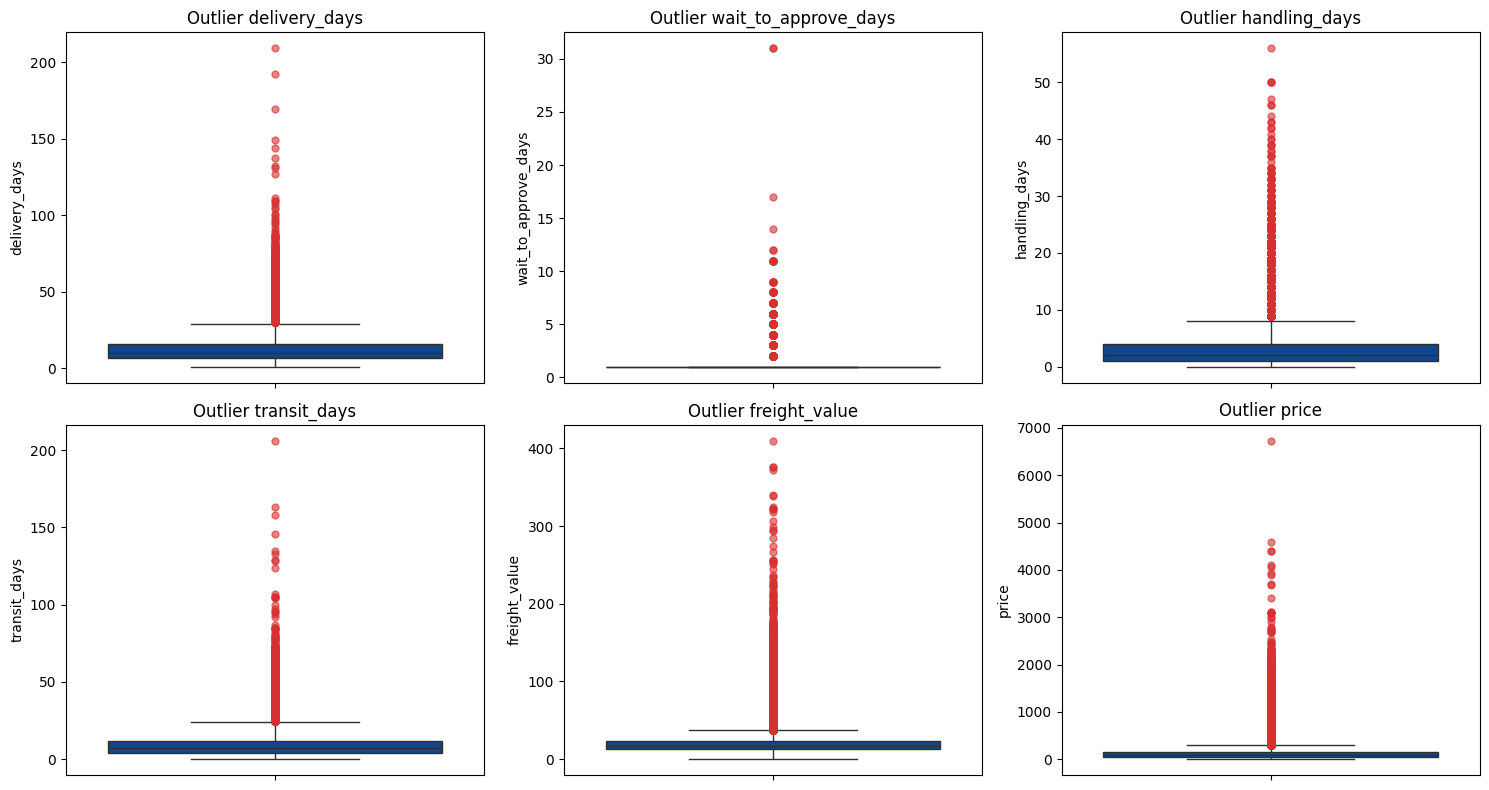

In [28]:
# Boxplot Visualization for Outlier Detection
focus_cols = ['delivery_days', 'wait_to_approve_days', 'handling_days', 'transit_days', 'freight_value', 'price']

plt.figure(figsize=(15, 8))
for i, col in enumerate(focus_cols, 1):
    plt.subplot(2, 3, i)
    
    sns.boxplot(
        y=order_level[col],
        color='#00439c',               
        flierprops=dict(
            marker='o',
            markerfacecolor='#d63031',       
            markeredgecolor='#d63031',
            markersize=5,
            alpha=0.6
        )
    )
    
    plt.title(f'Outlier {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

<div style="font-size:12px; text-align: justify;">
<p>
The boxplot shows that the data leans to the right and has some very high values called outliers. This matches the descriptive statistics and shows the natural differences in Brazil's logistics system, which covers a large area with different land shapes. These extreme values show cases of delays and high logistics costs that are real and not data mistakes. Therefore, the outliers are kept to help study logistic bottlenecks and their effect on customer satisfaction.
</p>
</div>

<div style="font-size:12px; text-align: justify;">

### Exploratory Data Analysis (EDA)</b>

<ul>
  <li>
    <b>Distribution of Delivery Days, Delivery SLA Gap, and Freight Value:</b><br>
    To understand the spread of delivery duration, the delay compared to the estimated delivery time, and the variation in shipping costs.
  </li>
  <li>
    <b>Percentage of Delivery SLA Gap:</b><br>
    To measure the proportion of late orders versus on-time orders as an initial indicator of logistics quality.
  </li>
  <li>
    <b>Top 10 States with Highest Late Delivery Rate:</b><br>
    To identify regions with the highest risk of late delivery and potential geographic bottlenecks.
  </li>
  <li>
    <b>Top 10 States with the Best On-Time Delivery Performance:</b><br>
    To compare regions with the best logistics performance as operational benchmarks.
  </li>
  <li>
    <b>Spearman Correlation (Review Score, Delivery Days, SLA Gap, Freight, Price, Handling, Transit):</b><br>
    To test non-linear relationships between logistics performance, costs, and customer satisfaction.
  </li>
  <li>
    <b>Customer Satisfaction Trend vs Delivery Duration:</b><br>
    To observe how increasing delivery duration affects the average customer review score.
  </li>
  <li>
    <b>Repeat Purchase Analysis: Loyalty Gap:</b><br>
    To measure the difference in repeat purchase rates between customers receiving on-time and late orders.
  </li>
</ul>

</div>

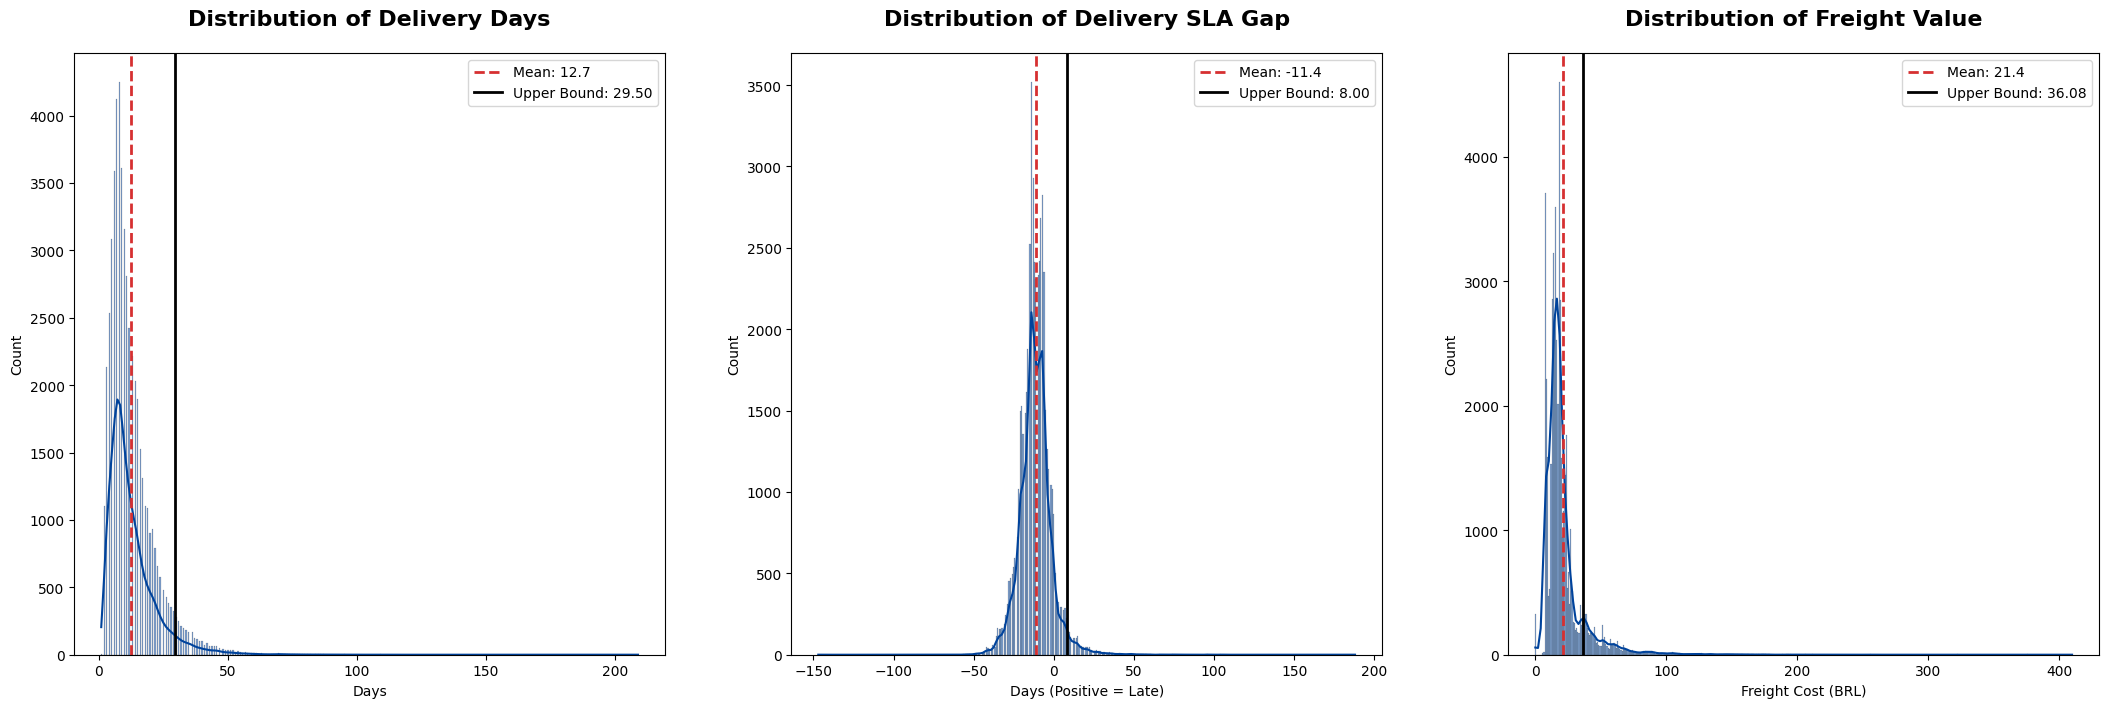

In [29]:
# Distribution of Delivery Days, Delivery SLA Gap, and freight_value
plt.rcParams['figure.dpi'] = 100
olist_blue = '#00439c'
olist_red = '#d63031'

# Pre-calculate means (clean & readable)
mean_delivery_days = order_level['delivery_days'].mean()
mean_sla_gap = order_level['delivery_sla_gap'].mean()
mean_freight = order_level['freight_value'].mean()

fig, ax = plt.subplots(1, 3, figsize=(22, 8))

# --- Distribution of Delivery Days ---
sns.histplot(
    order_level['delivery_days'],
    kde=True,
    color=olist_blue,
    ax=ax[0]
)
ax[0].axvline(
    mean_delivery_days,
    color=olist_red,
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_delivery_days:.1f}'
)
ax[0].axvline(
    29.50,
    color='black',
    linestyle='-',
    linewidth=2,
    label='Upper Bound: 29.50'
)
ax[0].set_title('Distribution of Delivery Days', fontsize=16, fontweight='bold', pad=20)
ax[0].set_xlabel('Days')
ax[0].legend()

# --- Distribution of Delivery SLA Gap ---
sns.histplot(
    order_level['delivery_sla_gap'],
    kde=True,
    color=olist_blue,
    ax=ax[1]
)
ax[1].axvline(
    mean_sla_gap,
    color=olist_red,
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_sla_gap:.1f}'
)
ax[1].axvline(
    8.00,
    color='black',
    linestyle='-',
    linewidth=2,
    label='Upper Bound: 8.00'
)
ax[1].set_title('Distribution of Delivery SLA Gap', fontsize=16, fontweight='bold', pad=20)
ax[1].set_xlabel('Days (Positive = Late)')
ax[1].legend()

# --- Distribution of Freight Value ---
sns.histplot(
    order_level['freight_value'],
    kde=True,
    color=olist_blue,
    ax=ax[2]
)
ax[2].axvline(
    mean_freight,
    color=olist_red,
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_freight:.1f}'
)
ax[2].axvline(
    36.08,
    color='black',
    linestyle='-',
    linewidth=2,
    label='Upper Bound: 36.08'
)
ax[2].set_title('Distribution of Freight Value', fontsize=16, fontweight='bold', pad=20)
ax[2].set_xlabel('Freight Cost (BRL)')
ax[2].legend()

plt.tight_layout(pad=4)
plt.show()

<div style="font-size:12px; text-align: justify;">

<b>Histogram Analysis</b>
<p>Based on the histograms above:</p>

<ul>
<li><b>Delivery days distribution:</b> Most orders are delivered in a short time, with a peak around 7–10 days. However, the data leans to the right (right-skewed), with a long tail over 200 days. This means most customers get their orders on time, but a few orders are very late. These extreme delays can strongly affect customer experience even if they are few.</li>

<li><b>Delivery SLA gap distribution:</b> This shows the difference between the estimated delivery date and the actual delivery date. Negative values mean orders arrive earlier, and positive values mean orders are late. The distribution is centered around negative values, meaning many orders arrive earlier than estimated. But there is still a long right tail, showing some orders are very late. Overall, SLA is met, but big delays cannot be ignored because customers remember bad experiences more than neutral ones.</li>

<li><b>Freight value distribution:</b> Most shipping costs are low to medium, but the distribution is very right-skewed, with some very high shipping costs. This means expensive shipping usually happens when the distance is long or the items are large.</li>
</ul>

</div>

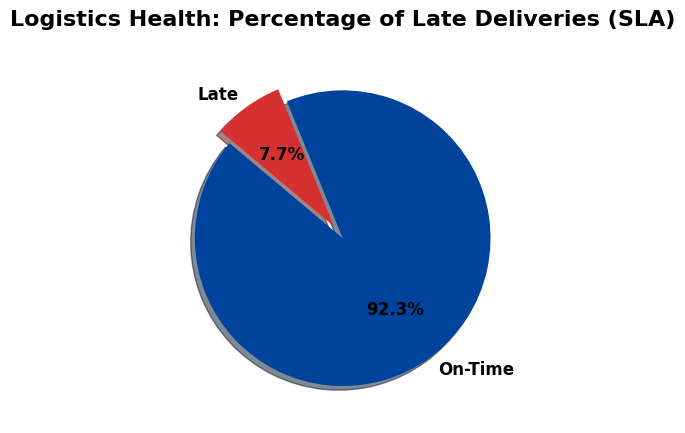

In [30]:
# Percentage of Delivery SLA Gap
late_counts = (
    order_level['is_late']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

labels = ['On-Time', 'Late']
colors = [olist_blue, olist_red]

plt.figure()

plt.pie(
    late_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=[0, 0.1],
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    shadow=True
)

plt.title('Logistics Health: Percentage of Late Deliveries (SLA)', fontsize=16, fontweight='bold', pad=20)
plt.show()

In [31]:
# Count number of On-Time vs Late orders
order_late_summary = (
    order_level['is_late']
    .value_counts()
    .rename({0: 'On-Time', 1: 'Late'})
    .reset_index()
)

order_late_summary.columns = ['Delivery Status', 'Total Orders']
order_late_summary

,Delivery Status,Total Orders
0,On-Time,48690
1,Late,4079


<div style="font-size:12px; text-align: justify;">
<b>Proportion of Delivery SLA (Late vs On-Time)</b>
<p>92.3% of orders are delivered on time or earlier than estimated, while 7.7% of orders are delayed. Overall, Olist's logistics performance looks very good based on the SLA percentage. However, even though the share of delayed orders is small, the business impact cannot be ignored.</p>
</div>

In [32]:
# Top 10 states with highest late delivery rate
top_10_problematic_states = (
    order_level
    .groupby('customer_state')
    .agg(
        total_orders=('order_id', 'nunique'),
        avg_delivery_days=('delivery_days', 'mean'),
        late_rate=('is_late', 'mean')
    )
    .reset_index()
    .sort_values('late_rate', ascending=False)
    .head(10)
)

top_10_problematic_states['late_rate'] = (top_10_problematic_states['late_rate'] * 100).round(2)

top_10_problematic_states = top_10_problematic_states.rename(columns={
    'customer_state': 'State',
    'total_orders': 'Total Orders',
    'avg_delivery_days': 'Avg Delivery Days',
    'late_rate': 'Late Delivery (%)'
})
top_10_problematic_states

,State,Total Orders,Avg Delivery Days,Late Delivery (%)
1,AL,198,24.17,22.22
9,MA,346,21.92,19.94
5,CE,633,22.67,19.12
16,PI,258,19.86,16.67
13,PA,453,26.02,16.56
24,SE,146,18.68,16.44
26,TO,144,18.81,15.28
11,MS,411,16.80,14.36
4,BA,1725,19.69,14.09
7,ES,1047,16.77,13.75


<div style="font-size:12px; text-align: justify;">

<b>Top 10 States with Highest Delays</b>
<p>Analysis of the 10 states with the highest delivery delays shows that delays are more influenced by geography than by order volume. States like Alagoas, Maranhão, Ceará, Pará, and Piauí have high delay percentages, with average delivery days above 21 and delay rates over 15%. On the other hand, states with many orders like BA and ES have high transaction volumes but still show late delivery above 13%. This means that the farther a state is from the main distribution center (for example, São Paulo), the longer the delivery time and the higher the risk of delays. States with few orders but high delays show limitations in logistics infrastructure or dependence on more complex delivery routes.</p>

</div>

In [33]:
# Top 10 States with the Best On-Time Delivery Performance
top_10_reliable_states = (
    order_level
    .groupby('customer_state')
    .agg(
        total_orders=('order_id', 'nunique'),
        avg_delivery_days=('delivery_days', 'mean'),
        late_rate=('is_late', 'mean')
    )
    .reset_index()
    .sort_values('late_rate', ascending=True)
    .head(10)
)

top_10_reliable_states['late_rate'] = (top_10_reliable_states['late_rate'] * 100).round(2)

top_10_reliable_states = top_10_reliable_states.rename(columns={
    'customer_state': 'State',
    'total_orders': 'Total Orders',
    'avg_delivery_days': 'Avg Delivery Days',
    'late_rate': 'Late Delivery (%)'
})
top_10_reliable_states

,State,Total Orders,Avg Delivery Days,Late Delivery (%)
3,AP,39,26.46,0.00
20,RO,109,20.79,3.67
0,AC,27,21.63,3.70
2,AM,72,27.79,4.17
17,PR,2711,12.14,4.76
25,SP,23324,8.85,5.00
12,MT,476,18.27,5.88
10,MG,6080,12.41,6.20
6,DF,1192,13.02,6.71
22,RS,2737,15.84,7.16


<div style="font-size:12px; text-align: justify;">
<b>Top 10 States with Lowest Delays</b>
<p>Analysis of the 10 states with the lowest delivery delays shows that states like AP, RO, AC, and AM have very low delay percentages (0–4%) but a small number of orders. States with high order volumes, such as SP (23,324 orders), MG, PR, and RS, are still able to keep late delivery under 7%. This means that states with many orders and low delays (for example, SP) have better logistics infrastructure close to main distribution centers and major sellers. Meanwhile, states with few orders and low delays do not always indicate very good logistics performance because the results can be influenced by the small amount of data.</p>

</div>

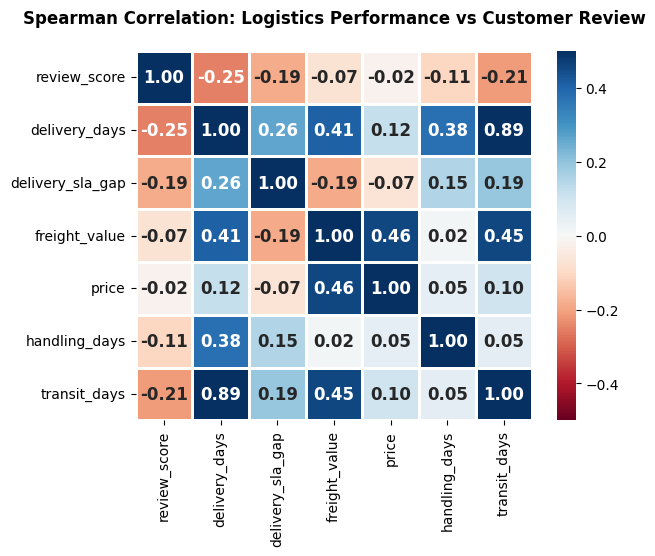

In [34]:
# Spearman Correlation of Review Score, Delivery Days, Delivery SLA Gap, Freight Value, Price, Handling Days', end Transit Days
cols_to_corr = ['review_score', 'delivery_days', 'delivery_sla_gap', 'freight_value', 'price', 'handling_days', 'transit_days']

corr_matrix = order_level[cols_to_corr].corr(method='spearman')

plt.figure()
plt.rcParams['figure.dpi'] = 100

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu', 
            center=0,
            vmin=-0.5, 
            vmax=0.5,
            linewidths=1, 
            linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'})

plt.title('Spearman Correlation: Logistics Performance vs Customer Review', 
          fontsize=12, 
          fontweight='bold', 
          pad=20)
plt.show()

<div style="font-size:12px; text-align: justify;">

<b>Spearman Correlation Analysis</b>
<p>This analysis uses Spearman correlation to see the relationship (not cause and effect) between logistics performance and review score. Spearman is used because the data is not normally distributed and there are many outliers. The results show:</p>

<ul>
<li><b>Review score and Delivery days:</b> -0.25. This means the longer the delivery, the lower the review score. The relationship is weak to moderate but consistent.</li>

<li><b>Transit days and Review score:</b> -0.21. Delays in the transit stage are related to lower satisfaction. Transit is the most sensitive stage for customers.</li>

<li><b>Delivery SLA gap and Review score:</b> -0.19. Orders that arrive later than estimated tend to get worse reviews.</li>

<li><b>Handling days and Review score:</b> -0.11. There is an effect, but it is smaller than transit.</li>

<li><b>Price and Review score:</b> -0.02, <b>Freight value and Review score:</b> -0.07. This means price and shipping cost have little direct effect on review score. Speed and delivery accuracy are more important than cost for customer satisfaction.</li>

<li><b>Delivery days and Transit days:</b> 0.89. This is very strong, meaning total delivery time is strongly influenced by the transit stage.</li>
</ul>

</div>

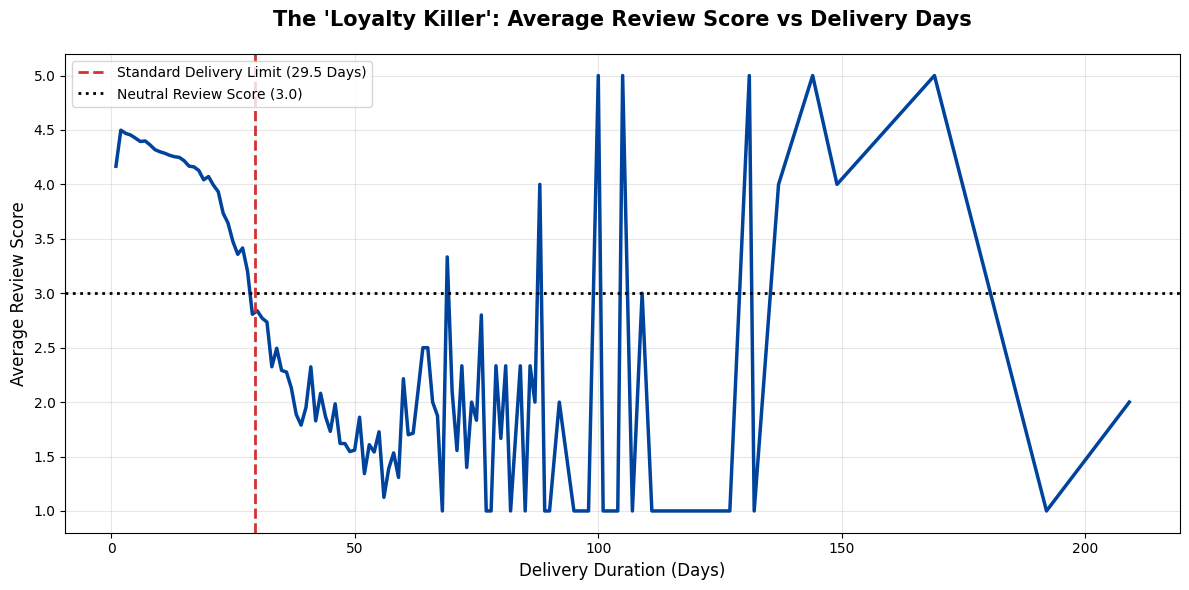

In [35]:
# Customer Satisfaction Trend (Average) vs Delivery Duration
# Average review_score per delivery_days
avg_review_per_day = (
    order_level
    .groupby('delivery_days', as_index=False)
    .agg(avg_review_score=('review_score', 'mean'))
)

plt.figure(figsize=(12, 6))
plt.rcParams['figure.dpi'] = 100

sns.lineplot(
    data=avg_review_per_day,
    x='delivery_days',
    y='avg_review_score',
    color=olist_blue,
    linewidth=2.5
)

plt.axvline(
    x=29.5,
    color='#d63031',
    linestyle='--',
    linewidth=2,
    label='Standard Delivery Limit (29.5 Days)'
)

plt.axhline(
    y=3,
    color='black',
    linestyle=':',
    linewidth=2,
    label='Neutral Review Score (3.0)'
)

plt.title(
    "The 'Loyalty Killer': Average Review Score vs Delivery Days",
    fontsize=15,
    fontweight='bold',
    pad=20
)
plt.xlabel('Delivery Duration (Days)', fontsize=12)
plt.ylabel('Average Review Score', fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div style="font-size:12px; text-align: justify;">
<b>Delivery Days vs Review Score</b>
<p>This chart shows the relationship between delivery days and the average customer review score. The main patterns are:</p>

<ul>
<li><b>Fast delivery (≤ 20 days):</b> The average review score is above 4, meaning customers are very satisfied.</li>

<li><b>Around 25–30 days:</b> The review score drops sharply, with the average falling below 3 (neutral).</li>

<li><b>Over 30 days:</b> Review scores are mostly low (1–2), showing strong customer dissatisfaction.</li>

</ul>
<p>The red vertical line (≈ 29.5 days) shows the standard delivery limit. After this point, customer satisfaction drops quickly. This does not mean every slow delivery gets a bad review. But the longer the delivery, the higher the risk of low reviews. There is a critical point (tipping point) around 30 days, showing that even small delays can become a big problem if they go past customer expectations.</p>

</div>

C:\Users\Asus\AppData\Local\Temp\ipykernel_21020\1549291483.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


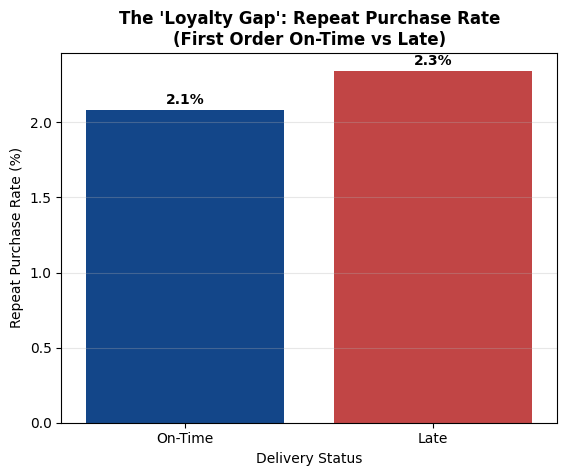

In [36]:
#Loyalty Gap (Repeat Purchase vs First Order Delivery Experience)
loyalty_analysis = (
    first_order_exp[['customer_unique_id', 'first_order_late']]
    .merge(
        customer_level[['customer_unique_id', 'is_repeat_customer']],
        on='customer_unique_id',
        how='left'
    )
    .groupby('first_order_late')['is_repeat_customer']
    .mean()
    .reset_index()
)

loyalty_analysis['Delivery Status'] = loyalty_analysis['first_order_late'].map({0: 'On-Time', 1: 'Late'})

loyalty_analysis['RepeatPercent'] = loyalty_analysis['is_repeat_customer'] * 100

plt.figure()
bars = sns.barplot(
    data=loyalty_analysis,
    x='Delivery Status',
    y='RepeatPercent',
    palette=[olist_blue, olist_red]
)

for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(
        f'{height:.1f}%',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 2),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

bars.set_ylabel('Repeat Purchase Rate (%)')
plt.title(
    "The 'Loyalty Gap': Repeat Purchase Rate\n(First Order On-Time vs Late)",
    fontsize=12,
    fontweight='bold'
)
plt.grid(axis='y', alpha=0.3)
plt.show()

<div style="font-size:12px; text-align: justify;">
<b>Repeat Purchase Analysis</b>
<p>This chart shows the percentage of customers who make a repeat purchase based on their first purchase experience. Later, we will see how many first orders that were on-time or late lead to repeat purchases. On-time orders have a 2.1% repeat purchase rate, while late orders have 2.3%. This does not mean that late delivery increases loyalty. The result is also affected by the number of orders and the number of on-time and late deliveries. Overall, the repeat purchase rate is very low (<3%). This means Olist is a need-based (transactional) marketplace. Loyalty is not the main driver; customers buy mainly because they need products. In other words, customers rarely come back, whether delivery is fast or slow.</p>

</div>

<div style="font-size:12px; text-align: justify;">

<b>Conclusion of EDA</b>
<p>The EDA shows that logistics performance has an important role in customer satisfaction, especially delivery time. Most orders are delivered on time (92.3%), but even small delays (7.7%) are enough to lower review scores. The data distribution shows many outliers in delivery days, transit days, and freight value, which indicate inconsistencies in the logistics process.</p>

<p>Correlation analysis shows a negative relationship between delivery days and review score. This means the longer the delivery, the lower the customer satisfaction. Performance differences between states are also clear: regions with longer average delivery times have higher delay percentages.</p>

<p>Although the repeat purchase rate is very low and almost the same for on-time and late deliveries, this shows that Olist is a need-based marketplace, not loyalty-driven. Therefore, the main business focus should be on improving delivery speed and consistency to maintain customer satisfaction. This will be analyzed further using statistical methods to confirm the impact of logistics on customer satisfaction and behavior.</p>

</div>

<div style="font-size:12px; text-align: justify;">

### Analysis Plan

<p>To answer the business problem, this analysis uses four related methods. Each method is used to see the relationship between delivery delays, customer satisfaction, and repeat purchase behavior.</p>

<ul>
<li><b>1. Logistics SLA Decomposition</b><br>
This analysis is used to see which part of the logistics process takes the longest time from order creation to delivery to the customer. The logistics process is divided into several stages:
<ul>
<li><b>wait_to_approve_days:</b> time from order creation to payment approval.</li>
<li><b>handling_days:</b> time from payment approval to handover to courier.</li>
<li><b>transit_days:</b> time from handover to courier until the customer receives the order.</li>
</ul>
Mean and median are used to compare the duration of each stage. The goal is to identify potential operational bottlenecks. This analysis is descriptive and does not determine the main cause.</li>

<li><b>2. Experience-Based Cohort Analysis (Repeat Purchase)</b><br>
This analysis looks at whether the first delivery experience affects the chance of a customer making a repeat purchase. Customers are divided into two groups based on their first order:
<ul>
<li><b>Group A:</b> customers with on-time first delivery.</li>
<li><b>Group B:</b> customers with late first delivery.</li>
</ul>
Then, the number of repeat purchases each month is calculated. This analysis shows differences in repeat purchase patterns between the two groups. It does not define churn but shows early customer loyalty patterns.</li>

<li><b>3. Negative Review Keyword Analysis</b><br>
This analysis is used to understand the main themes in customer complaints from negative review comments. Text analysis is performed on:
<ul>
<li><b>review_comment_message</b></li>
<li>Only for <b>review_score ≤ 3</b></li>
</ul>
The goals are:
<ul>
<li>To see if customer complaints are often related to delivery.</li>
<li>To validate the relationship between delivery delays and bad customer experiences.</li>
</ul>
This analysis focuses on keyword themes, not sentiment scores. (Add the specific text analysis method used, e.g., TF-IDF or word frequency.)</li>

<li><b>4. Mann Whitney U Test</b><br>
The Mann Whitney U Test is used to support the previous analysis with a statistical test. It answers the question: Is there a difference in review scores between customers with on-time and late deliveries? Mann–Whitney is chosen because:
<ul>
<li>Review score data is not normally distributed.</li>
<li>Comparison is between two different groups (On-time vs Late).</li>
</ul>
Statistical hypothesis:
<ul>
<li><b>H0:</b> There is no significant difference in review scores between on-time and late deliveries.</li>
<li><b>H1:</b> Customers with on-time delivery have higher review scores than customers with late delivery.</li>
</ul>
</li>
</ul>

</div>


Funnel Analysist

In [37]:
# Funnel Time Summary
# Summary statistics of each delivery stage
funnel_summary = (
    order_level[['wait_to_approve_days', 'handling_days', 'transit_days', 'delivery_days']]
    .describe()
    .loc[['mean', '50%', 'std']]
    .rename(index={'50%': 'median'})
    .T
    .round(2)
)
funnel_summary

,mean,median,std
wait_to_approve_days,1.26,1.00,0.73
handling_days,3.11,2.00,3.21
transit_days,9.71,7.00,8.69
delivery_days,12.69,10.00,9.44


In [38]:
# Logistics Health KPI (%)
# Percentage of orders that are on-time vs late
logistics_health = (
    order_level['is_late']
    .value_counts(normalize=True)
    .rename({0: 'On-Time', 1: 'Late'})
    .mul(100)
    .round(2)
    .to_frame(name='percentage')
)
logistics_health

,percentage
is_late,
On-Time,92.27
Late,7.73


In [39]:
# Botleneck Analysis by Customer State
# Identify top problematic states and best performing states
state_bottleneck = (
    order_level
    .groupby('customer_state')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('is_late', 'sum'),
        avg_sla_gap=('delivery_sla_gap', 'mean'),
        avg_transit_days=('transit_days', 'mean')
    )
    .assign(late_percentage=lambda df: df.late_orders / df.total_orders * 100)
    .round(2)
    .sort_values('late_percentage', ascending=False)
)

state_bottleneck['avg_sla_gap'] = state_bottleneck['avg_sla_gap'].fillna(0)

print('Top 10 Customer State Most problematic:')
display(state_bottleneck.head(10))

print('Top 10 Customer State Best Performers:')
display(state_bottleneck.tail(10))

Top 10 Customer State Most problematic:


,total_orders,late_orders,avg_sla_gap,avg_transit_days,late_percentage
customer_state,,,,,
AL,198,44,-8.78,20.80,22.22
MA,346,69,-7.24,18.66,19.94
CE,633,121,-8.50,19.82,19.12
PI,258,43,-9.95,16.66,16.67
PA,453,75,-12.11,22.89,16.56
SE,146,24,-10.75,15.89,16.44
TO,144,22,-10.35,15.42,15.28
MS,411,59,-9.73,13.67,14.36
BA,1725,243,-9.98,16.65,14.09


Top 10 Customer State Best Performers:


,total_orders,late_orders,avg_sla_gap,avg_transit_days,late_percentage
customer_state,,,,,
RS,2737,196,-13.81,12.92,7.16
DF,1192,80,-11.25,10.09,6.71
MG,6080,377,-12.65,9.40,6.20
MT,476,28,-14.12,15.13,5.88
SP,23324,1167,-10.38,5.91,5.00
PR,2711,129,-12.75,9.21,4.76
AM,72,3,-22.04,24.78,4.17
AC,27,1,-23.11,18.11,3.70
RO,109,4,-19.18,17.97,3.67


<div style="font-size:12px; text-align: justify;">

<b>Logistics SLA Decomposition</b>

<p>Interpretation:</p>
<ul>
<li><b>wait_to_approve_days:</b> The shortest stage with mean 1 day and median 1 day. Payment approval is fast and stable, so it is not the main bottleneck.</li>

<li><b>handling_days:</b> Mean 3 days and median 2 days with a large standard deviation. This shows variation in how sellers prepare orders. Some orders are fast, but others take longer, so seller handling starts to contribute to delays.</li>

<li><b>transit_days:</b> Mean 9 days and median 7 days with a high standard deviation. This shows that courier delivery is the longest and least stable stage in the logistics funnel.</li>

<li><b>delivery_days:</b> Total delivery time has mean 12.69 days and median 10 days. Because this is strongly influenced by transit_days, the main bottleneck is the transit stage (courier), not payment approval or seller handling.</li>
</ul>

<p>Business insight: Improving customer satisfaction and on-time delivery is more effective if focused on courier performance and delivery distance rather than only speeding up internal processes.</p>

</div>

Cohort Analysis

In [40]:
# 1. Cohort & Order Month
# Define the month of purchase and the customer's first purchase cohort
order_level = order_level.assign(order_month=order_level['order_purchase_timestamp'].dt.to_period('M'))

order_level['cohort'] = (
    order_level
    .groupby('customer_unique_id')['order_purchase_timestamp']
    .transform('min')
    .dt.to_period('M')
)

In [41]:
# 2. Cohort Index
# Calculate how many months after the first purchase each order occured
order_level['cohort_index'] = ((order_level['order_month'] - order_level['cohort']).apply(lambda x: x.n) + 1)

In [42]:
# 3. First Order Late Flag
# Identify if the customers first order was late
first_order_flag = first_order_exp.set_index('customer_unique_id')['first_order_late']

order_level['first_order_exp'] = order_level['customer_unique_id'].map(first_order_flag)

In [43]:
# 4. Cohort Counts
# Count unique customers per cohort and cohort index
cohort_counts = (
    order_level
    .groupby(['first_order_exp', 'cohort', 'cohort_index'])
    .agg(n_customers=('customer_unique_id', 'nunique'))
    .reset_index()
)

In [44]:
# 5. Built Retention Matrices
def build_retention_matrix(df, flag):
    matrix = (
        df[df['first_order_exp'] == flag]
        .pivot(index='cohort', columns='cohort_index', values='n_customers')
    )
    return matrix.divide(matrix.iloc[:, 0], axis=0) * 100

retention_on_time = build_retention_matrix(cohort_counts, 0)
retention_late = build_retention_matrix(cohort_counts, 1)

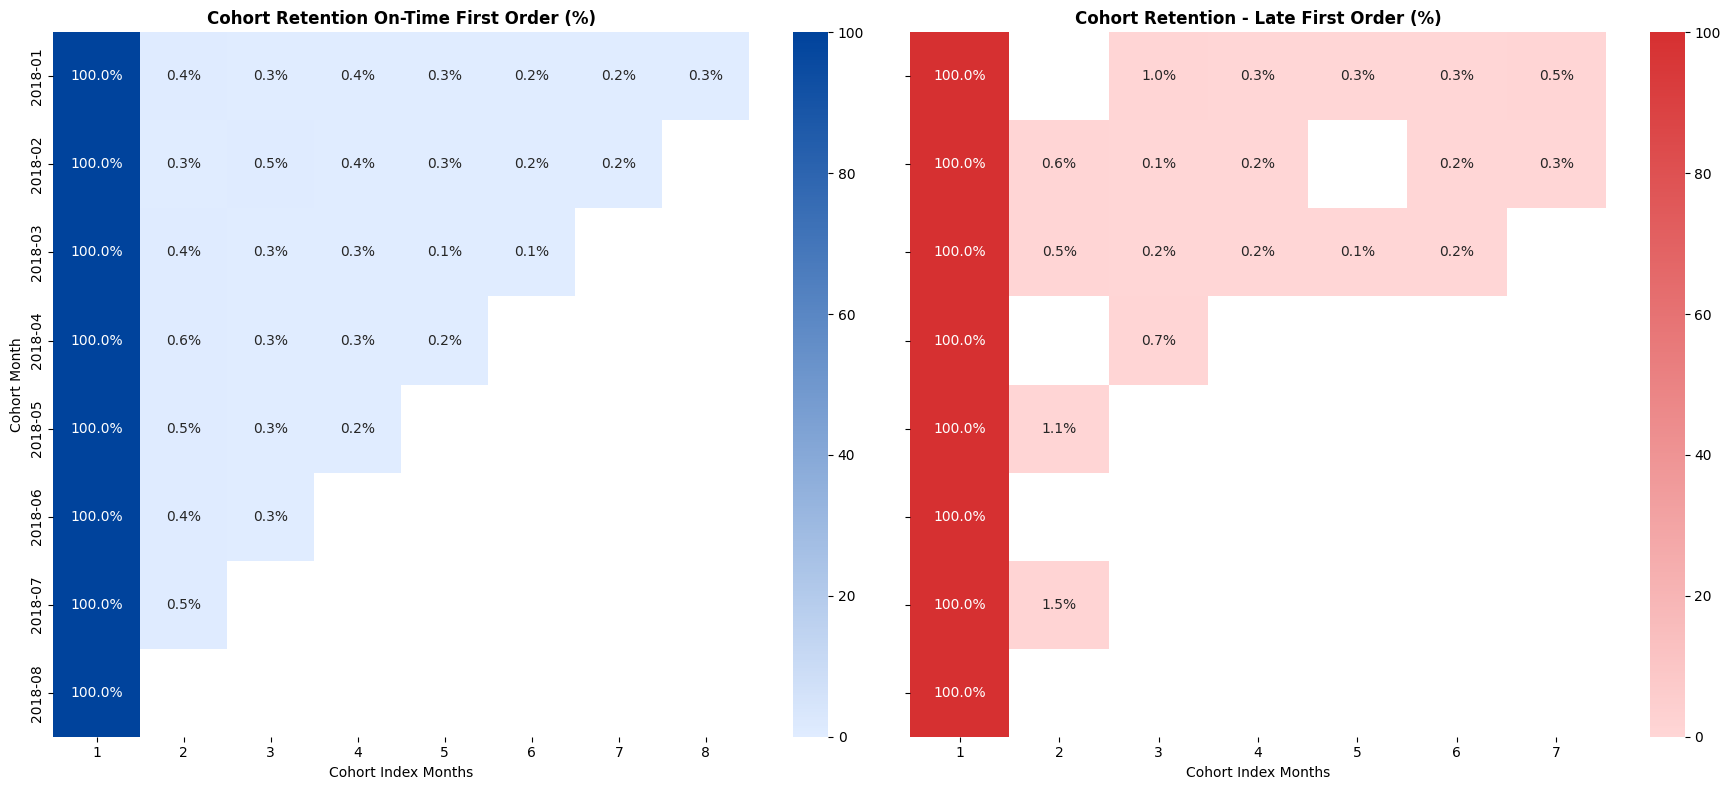

In [45]:
# Visualization Cohort Retention
blue_cmap = LinearSegmentedColormap.from_list("blue", ["#e0ecff", "#00439c"])
red_cmap  = LinearSegmentedColormap.from_list("red", ["#ffd6d6", "#d63031"])

# Create annotation strings with %
annot_on_time = retention_on_time.round(1).astype(str) + '%'
annot_late    = retention_late .round(1).astype(str) + '%'

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

sns.heatmap(
    retention_on_time,
    annot=annot_on_time,
    fmt='',
    cmap=blue_cmap,
    vmin=0,
    vmax=100,
    ax=axes[0]
)
axes[0].set_title('Cohort Retention On-Time First Order (%)', fontweight='bold')
axes[0].set_xlabel('Cohort Index Months')
axes[0].set_ylabel('Cohort Month')

sns.heatmap(
    retention_late,
    annot=annot_late,
    fmt='',
    cmap=red_cmap,
    vmin=0,
    vmax=100,
    ax=axes[1]
)
axes[1].set_title('Cohort Retention - Late First Order (%)', fontweight='bold')
axes[1].set_xlabel('Cohort Index Months')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

<div style="font-size:12px; text-align: justify;">
<b>Cohort Analysis: First Order Experience</b>

<p>The chart above compares customer retention based on the first order delivery experience: On-Time First Order and Late First Order. Each row shows the cohort month (the month a customer first buys), and each column shows the n-th month after the first order. The percentages show how many customers made a repeat purchase in that month.</p>

<p>Results show that retention for both groups is very low, with repeat purchase rates generally below 1% per month. This shows that Olist’s business model during this period naturally has low repeat rates. However, when comparing the two groups:</p>

<ul>
<li>Customers with on-time first orders have more stable and consistent retention over time.</li>
<li>Customers with late first orders have more fluctuating retention and it drops quickly, especially after the first month.</li>
</ul>

<p>Even though the percentage differences are small, they are important for business because:</p>
<ul>
<li>The first experience is a critical moment in forming loyalty.</li>
<li>Early delays can speed up churn.</li>
<li>On a large scale, small retention differences can significantly affect Customer Lifetime Value (CLV).</li>
<li>Thus, this cohort analysis supports the hypothesis that first-order delivery delays increase the risk of customer churn.</li>
</ul>

</div>

Sentiment Analysis

In [46]:
# 1. Filter Negative Reviews (Review Score ≤ 3), Late Order, and Non-empty Review Comments
late_negative_reviews = order_level[
    (order_level['review_score'] <= 3) &
    (order_level['is_late'] == 1) &
    (order_level['review_comment_message'].notna())
].copy()

In [47]:
# 2. Text Cleaning
late_negative_reviews['clean_review'] = (
    late_negative_reviews['review_comment_message']
    .str.lower()
    .str.replace(r'[^a-zà-ú\s]', '', regex=True)
)

In [48]:
# 3. Keyword Frequency (Raw)
from collections import Counter

words = ' '.join(late_negative_reviews['clean_review']).split()
word_freq = Counter(words)

common_words = pd.DataFrame(word_freq.most_common(20),columns=['word', 'frequency'])
common_words

,word,frequency
0,não,1596
1,o,1549
2,produto,1115
3,e,1005
4,a,802
5,de,734
6,recebi,648
7,que,596
8,ainda,489
9,entrega,466


In [49]:
# 4. Define Portuguese Stopwords
stopwords_pt = {
    # Articel/Prepotition
    'a','o','e','de','do','da','no','na','para','com','que',

    # common word
    'não','foi','ainda','até','pra',

    # pronoun
    'meu',

    # common
    'as','os'
}

In [50]:
# 5. Filter Meaningful Words
filtered_words = [
    word for word in words
    if word not in stopwords_pt and len(word) > 2
]

word_freq_clean = Counter(filtered_words)

common_words_clean = pd.DataFrame(word_freq_clean.most_common(20), columns=['word', 'frequency'])
common_words_clean

,word,frequency
0,produto,1115
1,recebi,648
2,entrega,466
3,prazo,310
4,entregue,251
5,dia,244
6,chegou,241
7,uma,205
8,comprei,186
9,estou,186


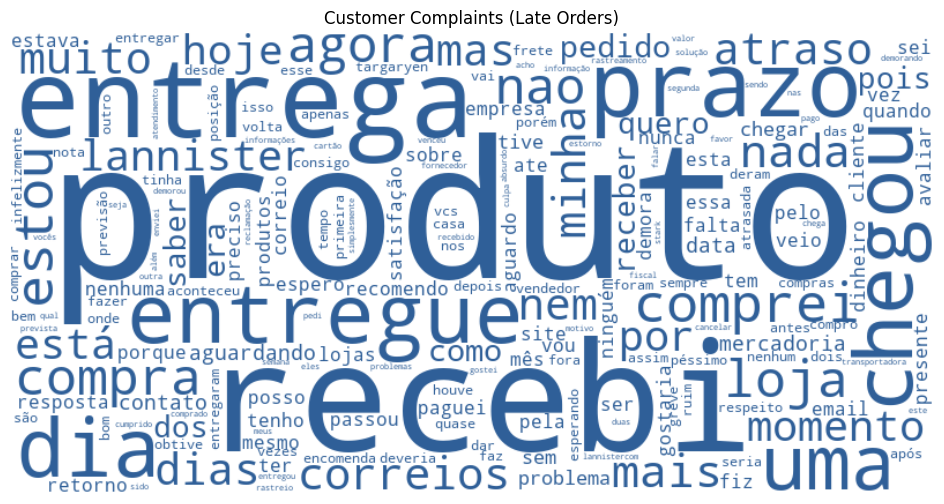

In [52]:
# 6. Word Cloud Visualization
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    color_func=lambda *args, **kwargs: '#2f5f98'
).generate_from_frequencies(word_freq_clean)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Customer Complaints (Late Orders)')
plt.show()


<div style="font-size:12px; text-align: justify;">
<b>Negative Review Keyword Analysis</b>

<p>This sentiment analysis uses a simple word frequency approach based on customer comments with <b>review_score &lt; 3</b>. The main goal is to understand whether negative reviews are related to delivery problems. The word frequency results show that the most common words are:</p>

<ul>
<li><b>Produto</b> (product)</li>
<li><b>Recebi</b> (I received)</li>
<li><b>Entrega / entregue</b> (delivery / delivered)</li>
<li><b>Prazo</b> (time / deadline)</li>
<li><b>Dia / chegou</b> (day / arrived)</li>
<li><b>Correios</b> (courier / postal service)</li>
</ul>

<p>The dominance of words related to delivery and time shows that customer complaints are not only about the product but are very often about delivery delays and delivery time not meeting expectations. Words like <b>“prazo”</b> (deadline) and <b>“correios”</b> (courier) show that customers clearly mention logistics problems in their negative reviews. This finding supports the previous analysis that delivery delays have a strong impact on customer satisfaction. Therefore, this sentiment analysis works as qualitative validation that low review scores are mainly caused by poor delivery experience, not only by product quality.</p>

</div>

Mann - Whitney U Test

In [53]:
# 1. Prepare the data for the two groups
# Group A: On-Time Orders (is_late == 0)
# Group B: Late Orders (is_late == 1)
group_a_scores = order_level.loc[(order_level['is_late'] == 0) & order_level['review_score'].notna(),'review_score']

group_b_scores = order_level.loc[(order_level['is_late'] == 1) & order_level['review_score'].notna(),'review_score']

In [55]:
# 2. heck if both groups have data
if len(group_a_scores) == 0 or len(group_b_scores) == 0:
    print('Mann-Whitney U Test cannot be performed because one of the groups is empty.')
else:
    print('Both groups have data, test can be performed.')

Both groups have data, test can be performed.


In [56]:
# 4. Perform Mann-Whitney U Test
# Alternative 'greater' tests whether on-time reviews > late reviews
stat, p_value = mannwhitneyu(group_a_scores, group_b_scores, alternative='greater')

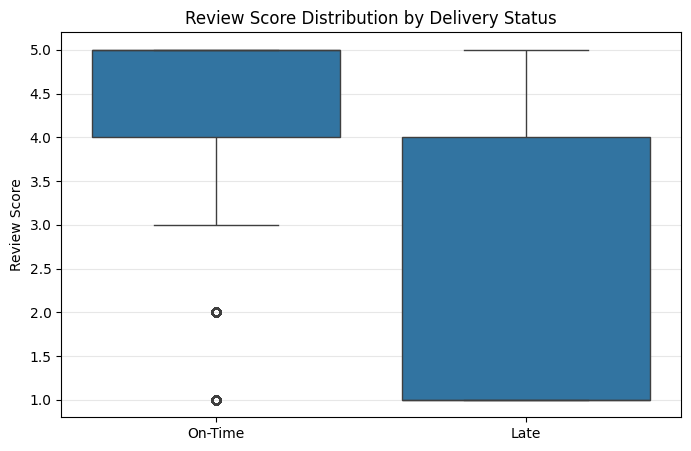

In [57]:
# 5. Visualize the distribution
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=order_level,
    x='is_late',
    y='review_score'
)
plt.xticks([0, 1], ['On-Time', 'Late'])
plt.title('Review Score Distribution by Delivery Status')
plt.ylabel('Review Score')
plt.xlabel('')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [58]:
# 6. Result Output
print('--- Mann-Whitney U Test Result ---')
print(f'U-Statistic     : {stat:.2f}')
print(f'P-Value         : {p_value:.4e}')
print(f'Median On-Time  : {group_a_scores.median()}')
print(f'Median Late     : {group_b_scores.median()}')

# 7. Interpretation
alpha = 0.05
if p_value < alpha:
    print('\nConclusion: Significant difference.')
    print('Late delivery is associated with lower customer review scores.')
else:
    print('\nConclusion: Not significant.')
    print('No strong statistical evidence that late delivery affects review scores.')

--- Mann-Whitney U Test Result ---
U-Statistic     : 159616917.50
P-Value         : 0.0000e+00
Median On-Time  : 5.0
Median Late     : 1.0

Conclusion: Significant difference.
Late delivery is associated with lower customer review scores.


<div style="font-size:12px; text-align: justify;">
<b>Mann–Whitney U Test Interpretation</b>

<p>The Mann–Whitney U Test is used to compare customer review scores between two different groups:</p>
<ul>
<li>Customers with on-time delivery (On-Time)</li>
<li>Customers with late delivery (Late)</li>
</ul>

<p>The test results show:</p>
<ul>
<li>Median review score On-Time = 5</li>
<li>Median review score Late = 1</li>
<li>P-value ≈ 0.000 (&lt; 0.05)</li>
</ul>

<p>Because the p-value is very small, we reject the null hypothesis (H0). This means there is a statistically significant difference between the review scores of customers who received orders on time and those who received them late.</p>

<p>Business insight: Delivery delays are strongly related to lower customer satisfaction. Customers with late deliveries tend to give much lower review scores, dropping from very satisfied (5) to very unsatisfied (1). This result supports previous findings from the funnel analysis, cohort analysis, and sentiment analysis, showing that logistics, especially delivery delays, are a key factor affecting customer perception and can lead to churn.</p>

</div>

<div style="font-size:12px; text-align: justify;">

<b>Conclusion</b>

<p>Based on the analysis of Olist 2018 data, we can conclude that logistics performance, especially delivery delays, has a direct impact on customer satisfaction and loyalty. Funnel analysis shows that the transit stage is the main bottleneck, with the longest average time compared to approval and handling stages. Although most orders (92.3%) are delivered on time, 7.7% of late orders are enough to reduce customer perception significantly. EDA and correlation results show that the longer the delivery time, the lower the customer review score, especially when delivery takes longer than normal. This is supported by sentiment analysis, where words related to delivery and delays dominate negative reviews. Cohort analysis shows that customers with late first orders have lower repeat purchase rates, indicating a higher churn risk from the first experience. Finally, the Mann–Whitney U Test provides strong statistical evidence that customers with late delivery give much lower review scores than customers with on-time delivery. Overall, these results show that even a small number of late deliveries can turn potential loyal customers into churn risk customers. Therefore, logistics is a key factor in maintaining Customer Lifetime Value (CLV).</p>

</div>

<div style="font-size:12px; text-align: justify;">

<b>Recommendations</b>

<p>Based on the analysis, Olist is recommended to manage the emotional impact on customers caused by delivery delays. Even though only 7.7% of orders are late, the effect on satisfaction is very large, with the median review score dropping from 5 to 1, and this difference is statistically significant. This drop in satisfaction is an early signal of churn risk, especially for first-time buyers. To reduce the impact, Olist can implement more transparent and proactive communication, such as:</p>

<ul>
<li>Early notification when there is a potential delay.</li>
<li>Empathy messages explaining the delivery situation.</li>
<li>Small compensation before the customer feels disappointed.</li>
</ul>

<p>By managing customer expectations and emotions better, Olist can maintain trust, reduce negative reviews, and keep customer loyalty even when delivery delays occur.</p>

</div>